# Lecture 9 Exercises - GPU Foundations

This notebook contains complete implementations for:
- Exercise 9.0: GPU introspection
- Exercise 9.1: chained vector addition
- Exercise 9.2: matrix multiplication analysis and implementation
- Exercise 9.3: Monte Carlo estimation of pi (Part 1)

The code is written to run even when CUDA is not available, but GPU sections require a CUDA-capable device.

In [8]:
from __future__ import annotations

import math
import subprocess
import time
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32

try:
    import cupy as cp
    CUPY_AVAILABLE = True
except Exception:
    cp = None
    CUPY_AVAILABLE = False

CUDA_AVAILABLE = cuda.is_available()

print(f"CUDA available: {CUDA_AVAILABLE}")
print(f"CuPy available: {CUPY_AVAILABLE}")


def timed(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed


def require_cuda() -> None:
    if not CUDA_AVAILABLE:
        raise RuntimeError("CUDA is required for this operation.")

CUDA available: False
CuPy available: False


## Exercise 9.0 - GPU Introspection

Goal:
- Run `nvidia-smi`
- Inspect key GPU properties from Python
- Connect hardware limits to kernel design choices (block size, occupancy, shared memory usage)

In [9]:
CUDA_CORES_PER_SM_BY_CC = {
    (2, 0): 32,
    (2, 1): 48,
    (3, 0): 192,
    (3, 5): 192,
    (3, 7): 192,
    (5, 0): 128,
    (5, 2): 128,
    (5, 3): 128,
    (6, 0): 64,
    (6, 1): 128,
    (6, 2): 128,
    (7, 0): 64,
    (7, 2): 64,
    (7, 5): 64,
    (8, 0): 64,
    (8, 6): 128,
    (8, 9): 128,
    (9, 0): 128,
}


def run_nvidia_smi() -> str:
    try:
        out = subprocess.run(
            ["nvidia-smi"],
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout
    except Exception as exc:
        return f"nvidia-smi unavailable: {exc}"


def gpu_introspection() -> Dict[str, object]:
    if not CUDA_AVAILABLE:
        return {"cuda_available": False}

    dev = cuda.get_current_device()
    cc = dev.compute_capability
    sm_count = int(dev.MULTIPROCESSOR_COUNT)
    cores_per_sm = CUDA_CORES_PER_SM_BY_CC.get(cc)

    return {
        "cuda_available": True,
        "name": dev.name.decode("utf-8") if isinstance(dev.name, bytes) else str(dev.name),
        "compute_capability": cc,
        "sm_count": sm_count,
        "cores_per_sm_estimate": cores_per_sm,
        "total_cuda_cores_estimate": (cores_per_sm * sm_count) if cores_per_sm else None,
        "clock_rate_khz": int(dev.CLOCK_RATE),
        "clock_rate_ghz": float(dev.CLOCK_RATE) / 1e6,
        "global_mem_bytes": int(dev.total_memory),
        "global_mem_gib": float(dev.total_memory) / (1024**3),
        "shared_mem_per_block_bytes": int(dev.MAX_SHARED_MEMORY_PER_BLOCK),
        "max_threads_per_block": int(dev.MAX_THREADS_PER_BLOCK),
        "warp_size": int(dev.WARP_SIZE),
    }


print("=== nvidia-smi ===")
print(run_nvidia_smi())

print("\n=== Introspection script output ===")
info = gpu_introspection()
for k, v in info.items():
    print(f"{k}: {v}")


def introspection_discussion(info: Dict[str, object]) -> None:
    print("\n=== Design discussion ===")
    if not info.get("cuda_available", False):
        print("No CUDA device detected, so hardware-specific design choices cannot be evaluated here.")
        return

    warp = info["warp_size"]
    max_tpb = info["max_threads_per_block"]
    shared_per_block = info["shared_mem_per_block_bytes"]

    print(f"1) Block size should be a multiple of warp size ({warp}) to avoid under-filled warps.")
    print(f"2) Upper bound for threads/block is {max_tpb}; practical choices are often 128, 256, or 512.")
    print(
        "3) Shared memory per block is "
        f"{shared_per_block} bytes; larger shared allocations can reduce active blocks/SM and occupancy."
    )
    print(
        "4) SM count and clock rate shape throughput: more SMs and higher clocks favor wider grids and enough work "
        "to keep all SMs busy."
    )
    print(
        "5) Global memory size limits problem size; memory bandwidth and access coalescing often dominate "
        "performance for memory-bound kernels."
    )


introspection_discussion(info)

=== nvidia-smi ===
nvidia-smi unavailable: Command '['nvidia-smi']' returned non-zero exit status 9.

=== Introspection script output ===
cuda_available: False

=== Design discussion ===
No CUDA device detected, so hardware-specific design choices cannot be evaluated here.


## Exercise 9.1 - Chained Vector Addition

Compute:
- `C = A + B`
- `D = C + E`

using NumPy (reference), CuPy, and a custom Numba CUDA kernel. Then benchmark transfer time vs kernel time as `N` grows from $10^3$ to $10^7$.

In [10]:
VECTOR_SIZES = [10**k for k in range(3, 8)]


def generate_vectors(n: int, seed: int = 0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    a = rng.random(n, dtype=np.float32)
    b = rng.random(n, dtype=np.float32)
    e = rng.random(n, dtype=np.float32)
    return a, b, e


def chain_numpy(a: np.ndarray, b: np.ndarray, e: np.ndarray) -> np.ndarray:
    c = a + b
    d = c + e
    return d


def chain_cupy(a: np.ndarray, b: np.ndarray, e: np.ndarray) -> np.ndarray:
    if not CUPY_AVAILABLE:
        raise RuntimeError("CuPy not available.")

    d = cp.asarray(a) + cp.asarray(b)
    d = d + cp.asarray(e)
    return cp.asnumpy(d)


@cuda.jit
def vec_add_kernel(x, y, out):
    idx = cuda.grid(1)
    if idx < out.size:
        out[idx] = x[idx] + y[idx]


def chain_numba_cuda(a: np.ndarray, b: np.ndarray, e: np.ndarray) -> np.ndarray:
    require_cuda()
    n = a.size
    threads_per_block = 256
    blocks = math.ceil(n / threads_per_block)

    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)
    d_e = cuda.to_device(e)
    d_c = cuda.device_array_like(d_a)
    d_d = cuda.device_array_like(d_a)

    vec_add_kernel[blocks, threads_per_block](d_a, d_b, d_c)
    vec_add_kernel[blocks, threads_per_block](d_c, d_e, d_d)
    cuda.synchronize()

    return d_d.copy_to_host()


def verify_chain_addition(n: int = 100_000) -> None:
    a, b, e = generate_vectors(n, seed=42)
    ref = chain_numpy(a, b, e)

    if CUDA_AVAILABLE:
        out_numba = chain_numba_cuda(a, b, e)
        np.testing.assert_allclose(out_numba, ref, rtol=1e-6, atol=1e-6)
        print("Numba CUDA chain addition matches NumPy reference.")
    else:
        print("Skipping Numba CUDA verification (no CUDA).")

    if CUPY_AVAILABLE:
        out_cupy = chain_cupy(a, b, e)
        np.testing.assert_allclose(out_cupy, ref, rtol=1e-6, atol=1e-6)
        print("CuPy chain addition matches NumPy reference.")
    else:
        print("Skipping CuPy verification (CuPy unavailable).")


verify_chain_addition()

Skipping Numba CUDA verification (no CUDA).
Skipping CuPy verification (CuPy unavailable).


       N method  transfer_h2d_s  kernel_s  transfer_d2h_s  transfer_total_s  total_s
    1000  numpy             0.0  0.000016             0.0               0.0 0.000016
   10000  numpy             0.0  0.000021             0.0               0.0 0.000021
  100000  numpy             0.0  0.000246             0.0               0.0 0.000246
 1000000  numpy             0.0  0.006961             0.0               0.0 0.006961
10000000  numpy             0.0  0.077670             0.0               0.0 0.077670


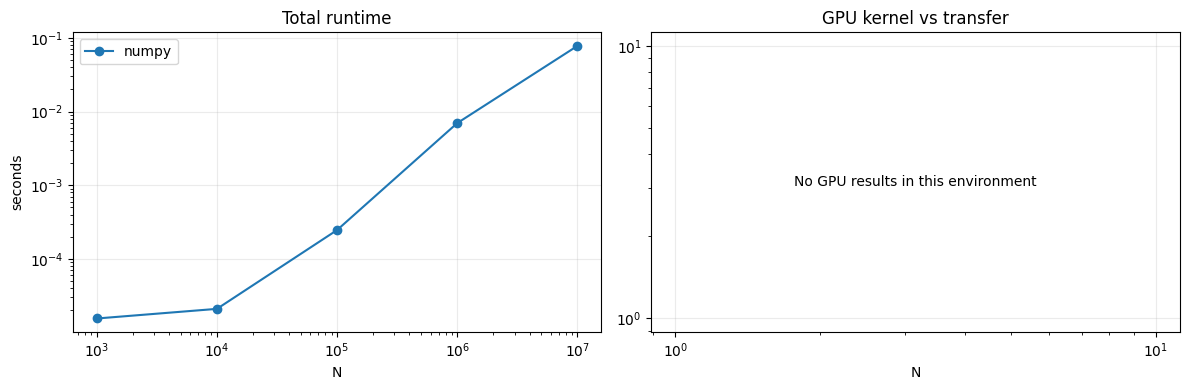

In [11]:
def benchmark_chain_numba(n: int, seed: int = 0) -> Dict[str, float]:
    require_cuda()
    a, b, e = generate_vectors(n, seed=seed)

    threads_per_block = 256
    blocks = math.ceil(n / threads_per_block)

    t0 = time.perf_counter()
    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)
    d_e = cuda.to_device(e)
    d_c = cuda.device_array_like(d_a)
    d_d = cuda.device_array_like(d_a)
    cuda.synchronize()
    transfer_h2d_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    vec_add_kernel[blocks, threads_per_block](d_a, d_b, d_c)
    vec_add_kernel[blocks, threads_per_block](d_c, d_e, d_d)
    cuda.synchronize()
    kernel_s = time.perf_counter() - t1

    t2 = time.perf_counter()
    out = d_d.copy_to_host()
    cuda.synchronize()
    transfer_d2h_s = time.perf_counter() - t2

    ref = chain_numpy(a, b, e)
    np.testing.assert_allclose(out, ref, rtol=1e-6, atol=1e-6)

    return {
        "N": n,
        "method": "numba_cuda",
        "transfer_h2d_s": transfer_h2d_s,
        "kernel_s": kernel_s,
        "transfer_d2h_s": transfer_d2h_s,
        "transfer_total_s": transfer_h2d_s + transfer_d2h_s,
        "total_s": transfer_h2d_s + kernel_s + transfer_d2h_s,
    }


def benchmark_chain_cupy(n: int, seed: int = 0) -> Dict[str, float]:
    if not CUPY_AVAILABLE:
        raise RuntimeError("CuPy not available.")

    a, b, e = generate_vectors(n, seed=seed)
    stream = cp.cuda.Stream.null

    t0 = time.perf_counter()
    d_a = cp.asarray(a)
    d_b = cp.asarray(b)
    d_e = cp.asarray(e)
    stream.synchronize()
    transfer_h2d_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    d = d_a + d_b
    d = d + d_e
    stream.synchronize()
    kernel_s = time.perf_counter() - t1

    t2 = time.perf_counter()
    out = cp.asnumpy(d)
    stream.synchronize()
    transfer_d2h_s = time.perf_counter() - t2

    ref = chain_numpy(a, b, e)
    np.testing.assert_allclose(out, ref, rtol=1e-6, atol=1e-6)

    return {
        "N": n,
        "method": "cupy",
        "transfer_h2d_s": transfer_h2d_s,
        "kernel_s": kernel_s,
        "transfer_d2h_s": transfer_d2h_s,
        "transfer_total_s": transfer_h2d_s + transfer_d2h_s,
        "total_s": transfer_h2d_s + kernel_s + transfer_d2h_s,
    }


def benchmark_chain_numpy(n: int, seed: int = 0) -> Dict[str, float]:
    a, b, e = generate_vectors(n, seed=seed)
    _, elapsed = timed(chain_numpy, a, b, e)
    return {
        "N": n,
        "method": "numpy",
        "transfer_h2d_s": 0.0,
        "kernel_s": elapsed,
        "transfer_d2h_s": 0.0,
        "transfer_total_s": 0.0,
        "total_s": elapsed,
    }


def run_chain_benchmarks(sizes: Sequence[int] = VECTOR_SIZES) -> pd.DataFrame:
    rows: List[Dict[str, float]] = []
    for n in sizes:
        rows.append(benchmark_chain_numpy(n))
        if CUDA_AVAILABLE:
            rows.append(benchmark_chain_numba(n))
        if CUPY_AVAILABLE:
            rows.append(benchmark_chain_cupy(n))
    return pd.DataFrame(rows)


def plot_chain_benchmarks(results: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for method, g in results.groupby("method"):
        g = g.sort_values("N")
        axes[0].plot(g["N"], g["total_s"], marker="o", label=method)

    gpu = results[results["method"].isin(["numba_cuda", "cupy"])]
    if gpu.empty:
        axes[1].text(
            0.5,
            0.5,
            "No GPU results in this environment",
            transform=axes[1].transAxes,
            ha="center",
            va="center",
        )
    else:
        for method, g in gpu.groupby("method"):
            g = g.sort_values("N")
            axes[1].plot(g["N"], g["kernel_s"], marker="o", label=f"{method}: kernel")
            axes[1].plot(g["N"], g["transfer_total_s"], marker="s", linestyle="--", label=f"{method}: transfer")

    for ax in axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("N")
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend()

    axes[0].set_title("Total runtime")
    axes[0].set_ylabel("seconds")
    axes[1].set_title("GPU kernel vs transfer")

    fig.tight_layout()
    plt.show()


chain_results = run_chain_benchmarks()
print(chain_results.to_string(index=False))
plot_chain_benchmarks(chain_results)

if "numba_cuda" in set(chain_results["method"]):
    pivot = chain_results[chain_results["method"] == "numba_cuda"].copy()
    pivot["kernel_over_transfer"] = pivot["kernel_s"] / np.maximum(pivot["transfer_total_s"], 1e-15)
    print("\nNumba: kernel-to-transfer ratio (>1 means compute dominates transfer)")
    print(pivot[["N", "kernel_s", "transfer_total_s", "kernel_over_transfer"]].to_string(index=False))

## Exercise 9.2 - Matrix Multiplication Analysis

For $C = AB$ with $A \in \mathbb{R}^{n \times m}$ and $B \in \mathbb{R}^{m \times p}$:

- Multiply-add operations: $nmp$ multiplications and $nmp$ additions if counting each multiply and add separately, or $nmp$ fused multiply-add operations if counting FMA pairs.
- Memory (float32, 4 bytes):
  - $A$: $4nm$ bytes
  - $B$: $4mp$ bytes
  - $C$: $4np$ bytes
  - Total: $4(nm + mp + np)$ bytes

Each element $C_{ij}$ is independent once $A$ and $B$ are fixed. That independence maps naturally to GPU parallelism: assign each output element (or tile of output elements) to independent threads/thread blocks.

In [12]:
def matmul_naive_python(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    n, m = a.shape
    m2, p = b.shape
    if m != m2:
        raise ValueError("Incompatible dimensions.")

    c = np.zeros((n, p), dtype=np.float32)
    for i in range(n):
        for j in range(p):
            acc = 0.0
            for k in range(m):
                acc += float(a[i, k]) * float(b[k, j])
            c[i, j] = acc
    return c


def matmul_numpy(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return a @ b


def matmul_cupy(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    if not CUPY_AVAILABLE:
        raise RuntimeError("CuPy not available.")
    return cp.asnumpy(cp.matmul(cp.asarray(a), cp.asarray(b)))


def memory_bytes_float32(n: int, m: int, p: int) -> Dict[str, int]:
    return {
        "A_bytes": 4 * n * m,
        "B_bytes": 4 * m * p,
        "C_bytes": 4 * n * p,
        "total_bytes": 4 * (n * m + m * p + n * p),
    }


n, m, p = 64, 96, 80
rng = np.random.default_rng(1)
a = rng.random((n, m), dtype=np.float32)
b = rng.random((m, p), dtype=np.float32)

c_naive, t_naive = timed(matmul_naive_python, a, b)
c_np, t_np = timed(matmul_numpy, a, b)
np.testing.assert_allclose(c_naive, c_np, rtol=1e-4, atol=1e-4)

print("Naive Python matches NumPy.")
print(f"naive_python: {t_naive:.6f} s")
print(f"numpy @:      {t_np:.6f} s")

if CUPY_AVAILABLE:
    c_cp, t_cp = timed(matmul_cupy, a, b)
    np.testing.assert_allclose(c_cp, c_np, rtol=1e-4, atol=1e-4)
    print(f"cupy.matmul:  {t_cp:.6f} s")
else:
    print("CuPy unavailable; skipping cp.matmul timing.")

print("\nMemory requirement for float32 matrices:")
print(memory_bytes_float32(n, m, p))

Naive Python matches NumPy.
naive_python: 0.195768 s
numpy @:      0.000079 s
CuPy unavailable; skipping cp.matmul timing.

Memory requirement for float32 matrices:
{'A_bytes': 24576, 'B_bytes': 30720, 'C_bytes': 20480, 'total_bytes': 75776}


## Exercise 9.3 - Monte Carlo Estimation of pi (Part 1)

Each GPU thread generates one random point $(x, y)$, records whether it lands in the quarter circle, and writes one hit flag. We copy all hit flags back to CPU and compute the final sum there.

This intentionally transfers $N$ booleans to host memory so we can compare it later to Lecture 10 reduction-based approaches.

In [13]:
@cuda.jit
def monte_carlo_pi_kernel(states, hits):
    idx = cuda.grid(1)
    if idx < hits.size:
        x = xoroshiro128p_uniform_float32(states, idx)
        y = xoroshiro128p_uniform_float32(states, idx)
        hits[idx] = 1 if (x * x + y * y) <= 1.0 else 0


def estimate_pi_gpu_transfer_all(n_samples: int, seed: int = 0) -> Dict[str, float]:
    require_cuda()

    threads_per_block = 256
    blocks = math.ceil(n_samples / threads_per_block)

    t0 = time.perf_counter()
    states = create_xoroshiro128p_states(n_samples, seed=seed)
    d_hits = cuda.device_array(n_samples, dtype=np.uint8)
    cuda.synchronize()
    setup_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    monte_carlo_pi_kernel[blocks, threads_per_block](states, d_hits)
    cuda.synchronize()
    kernel_s = time.perf_counter() - t1

    t2 = time.perf_counter()
    hits = d_hits.copy_to_host()
    cuda.synchronize()
    transfer_s = time.perf_counter() - t2

    c = int(hits.sum())
    pi_est = 4.0 * c / n_samples

    return {
        "N": n_samples,
        "pi_estimate": pi_est,
        "abs_error": abs(pi_est - math.pi),
        "setup_s": setup_s,
        "kernel_s": kernel_s,
        "transfer_s": transfer_s,
        "total_s": setup_s + kernel_s + transfer_s,
        "gpu_to_cpu_bytes": hits.nbytes,
    }


if CUDA_AVAILABLE:
    pi_sizes = [10**6, 5 * 10**6, 10**7]
    pi_rows = [estimate_pi_gpu_transfer_all(n, seed=123) for n in pi_sizes]
    pi_df = pd.DataFrame(pi_rows)
    print(pi_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(pi_df["N"], pi_df["kernel_s"], marker="o", label="kernel")
    ax.plot(pi_df["N"], pi_df["transfer_s"], marker="s", label="transfer")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("N")
    ax.set_ylabel("seconds")
    ax.set_title("Exercise 9.3: kernel vs transfer")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

    print(
        "\nThink-ahead note: this version transfers N boolean values to host only to compute one sum. "
        "A GPU-side reduction (Lecture 10) avoids most of this transfer overhead."
    )
else:
    print("CUDA unavailable; 9.3 kernel is defined but benchmark is skipped.")

CUDA unavailable; 9.3 kernel is defined but benchmark is skipped.


## Summary

- Exercise 9.0 reports GPU specs and links them to kernel design decisions.
- Exercise 9.1 compares NumPy, CuPy, and Numba CUDA chained addition and separates transfer from kernel time.
- Exercise 9.2 covers operation count, memory cost, naive loop implementation, correctness, and speed comparison with NumPy/CuPy.
- Exercise 9.3 implements GPU Monte Carlo pi with host-side summation, setting up the motivation for GPU reductions in Lecture 10.